# 71 — The phase ramp: a wrong answer, and the right one

We spent a while believing there was **no linear-in-frequency structure** in this
data's phase. That was wrong, and it was wrong for an interesting reason: we
measured a circular quantity with a straight-line ruler.

This notebook shows the whole path — the original test, why it lied, the fix
(measure with `cos`/`sin` instead), and what the corrected answer actually is.

**The punchline, up front:**

| claim | old (wrong) | new (correct) |
|---|---|---|
| Is there a linear-in-`f` ramp? | no | **yes, and it's large** |
| Should we fit and subtract it? | can't, nothing to fit | **no — fitting makes things worse** |
| What should we do? | structural cancellation | structural cancellation |

The *recommendation* survived. The *reason* flipped completely. That matters,
because a wrong reason predicts wrong things next time.

## 1 Setup

We read the complex64 MDS shards directly. `streaming` doesn't know about complex
dtypes, so we patch its encoding table exactly as `src/model/dataset.py:16-18` does.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from streaming.base.format.mds.encodings import _encodings
_N = _encodings['ndarray']                      # complex64 patch, cf. dataset.py:16-18
_N._int2value_dtype |= {100: 'complex64', 101: 'complex128'}
_N._value_dtype2int |= {'complex64': 100, 'complex128': 101}
from streaming import StreamingDataset

REPO = Path('/home/ethantu/workspace/good-vibrations')
EXP  = REPO / 'experiments/31_07_2026_gastronorm_exp1'
MDS  = EXP / 'mds/a49dd5e4473775d8'

meta  = [json.loads(l) for l in (MDS / 'metadata.jsonl').read_text().strip().splitlines() if l]
freqs = np.load(MDS / 'freqs.npy')
ds    = StreamingDataset(local=str(MDS), shuffle=False, batch_size=1)
DF    = float(freqs[1] - freqs[0])

def get(i):
    """(L, F, C) complex64 for sample i."""
    X = ds[i]['X']
    return X[0] if X.ndim == 4 else X

X0 = get(0)
print(f'{len(ds)} samples | {X0.shape[0]} lasers x {X0.shape[1]} bins x {X0.shape[2]} channels')
print(f'df = {DF:.4f} Hz, band {freqs[0]:.0f}-{freqs[-1]:.0f} Hz')

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


3007 samples | 100 lasers x 1235 bins x 2 channels
df = 0.7692 Hz, band 51-1000 Hz


## 2 What we're looking for

A time delay `tau` multiplies the spectrum by a phasor:

$$x(t-\tau) \;\longleftrightarrow\; X(f)\,e^{-2\pi i f \tau}$$

so it **adds a straight line** to the phase: $\Delta\phi(f) = -2\pi\tau f$. Magnitude
is untouched. This is the shift theorem, and it's the whole reason phase looked
useless in this project — camera and audio are triggered independently, so every
recording gets its own unknown `tau`.

The standard trick: a straight line has a **constant derivative**. So look at the
bin-to-bin phase difference

$$d\phi(f) \;=\; \angle\!\big(z(f{+}\Delta f)\,\overline{z(f)}\big)$$

If the phase were a pure ramp, `dphi` would be the *same number at every frequency*.

> **So the question "is there a linear-in-f ramp?" becomes "is `dphi` constant?"**

That's the test. Everything below is about measuring "constant" correctly.

In [2]:
def dphi(X):
    """Wrapped bin-to-bin phase difference, (L, F-1, C)."""
    return np.angle(X[:, 1:, :] * np.conj(X[:, :-1, :]))

def pair_weight(X):
    """Magnitude weight for each bin PAIR: |z(f)|*|z(f+df)|."""
    return np.abs(X[:, 1:, :]) * np.abs(X[:, :-1, :])

d0 = dphi(X0)
print('dphi shape', d0.shape, '| range', f'[{d0.min():.2f}, {d0.max():.2f}] rad')

dphi shape (100, 1234, 2) | range [-3.14, 3.14] rad


## 3 The original test — and its verdict

Take `dphi`, subtract its mean (the best-fit constant delay), and see how much
spread is left. The original run reported:

```python
res = d - d.mean(axis=1, keepdims=True)
std(d)   = 1.8591
std(res) = 1.8581      ->  ratio 1.00
```

Removing the best-fit delay removed **0.05%** of the spread. And `1.86 rad` is
suspiciously close to `1.81 rad`, which is the standard deviation of a *uniform*
distribution on $[-\pi, \pi]$ — i.e. pure noise.

The conclusion drawn was: *`dphi` is basically random, there is no constant to
find, there is no ramp.*

Let's reproduce it. (The cell below runs on a single sample, so its `std` comes
out slightly lower than the pooled figure above — but the **ratio**, which is the
whole basis of the argument, is identical.)

In [3]:
d = dphi(X0)
res = d - d.mean(axis=1, keepdims=True)

uniform_std = np.pi / np.sqrt(3)     # std of Uniform(-pi, pi)
print(f'std(dphi) = {d.std():.4f} rad')
print(f'std(res)  = {res.std():.4f} rad')
print(f'ratio     = {res.std() / d.std():.4f}')
print(f'\nstd of Uniform(-pi,pi) = {uniform_std:.4f} rad   <- our value sits right at the noise floor')

std(dphi) = 1.8001 rad
std(res)  = 1.7989 rad
ratio     = 0.9994

std of Uniform(-pi,pi) = 1.8138 rad   <- our value sits right at the noise floor


## 4 Why that test is broken

Two independent bugs, either one fatal.

### Bug 1 — subtracting a constant from a circular variable is a no-op

Phase lives on a **circle**. Adding a constant to every angle just *rotates* the
circle. It cannot change how tightly the angles are clustered — and "how tightly
clustered" is exactly what we were trying to measure.

So `std(res)/std(d) = 1.00` was never evidence of anything. **It's forced to be
~1 no matter what the data looks like.** The test had no power.

### Bug 2 — `std()` on wrapped angles reports nonsense

`np.angle` returns values in $[-\pi, \pi]$. If the true `dphi` is concentrated
around $\pi$, half the samples get reported as $\approx +\pi$ and half as
$\approx -\pi$. They're **the same angle** — but `std()` sees them as maximally
far apart and reports ~1.81 rad, the noise value.

A tight cluster sitting on the wrap point is indistinguishable from pure noise,
*if you use `std`*.

Here is that failure in one picture.

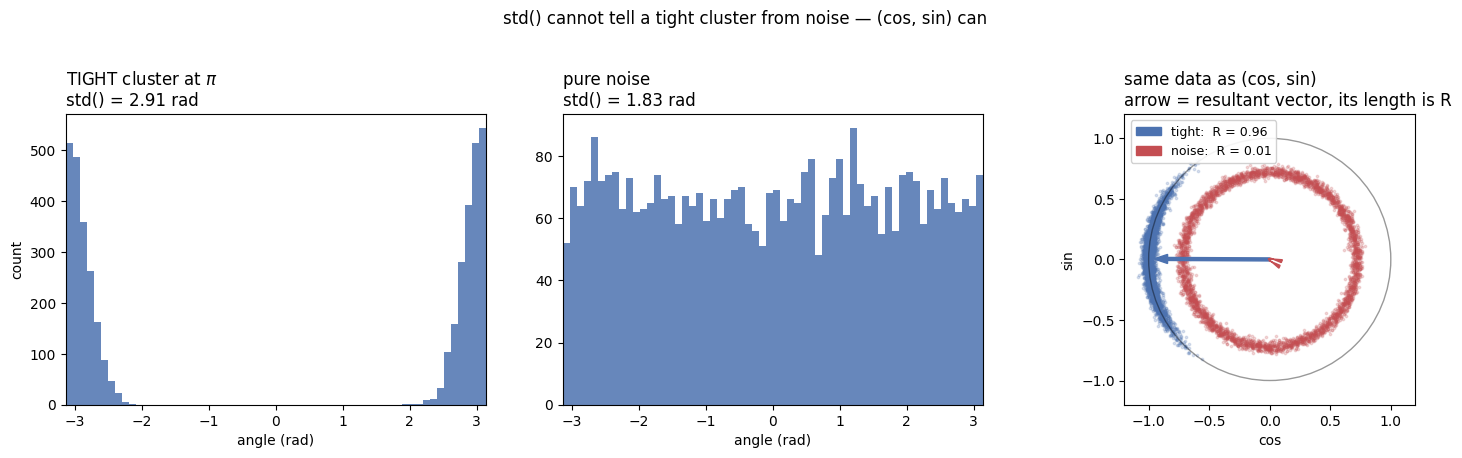

In [4]:
rng = np.random.default_rng(0)
n = 4000
# a TIGHT cluster (std 0.3 rad) that happens to sit at the wrap point
tight = np.angle(np.exp(1j * (np.pi + 0.3 * rng.standard_normal(n))))
noise = rng.uniform(-np.pi, np.pi, n)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, (v, name) in zip(axes[:2], [(tight, 'TIGHT cluster at $\\pi$'), (noise, 'pure noise')]):
    ax.hist(v, bins=60, range=(-np.pi, np.pi), color='#4C72B0', alpha=.85)
    ax.set_title(f'{name}\nstd() = {v.std():.2f} rad', loc='left')
    ax.set_xlabel('angle (rad)'); ax.set_xlim(-np.pi, np.pi)
axes[0].set_ylabel('count')

# (cos, sin) view. Radii are jittered ONLY so the two clouds don't overlap --
# every point is really on the unit circle.
ax = axes[2]
for v, name, c, r0 in [(tight, 'tight', '#4C72B0', 1.00), (noise, 'noise', '#C44E52', 0.72)]:
    r = r0 + 0.025 * rng.standard_normal(n)
    ax.scatter(r * np.cos(v), r * np.sin(v), s=3, alpha=.20, color=c)
    mu = np.exp(1j * v).mean()
    ax.arrow(0, 0, mu.real, mu.imag, width=.025, color=c, length_includes_head=True,
             zorder=5, label=f'{name}:  R = {abs(mu):.2f}')
ax.add_artist(plt.Circle((0, 0), 1, fill=False, lw=1, color='k', alpha=.4))
ax.set_aspect('equal'); ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.set_title('same data as (cos, sin)\narrow = resultant vector, its length is R', loc='left')
ax.legend(loc='upper left', fontsize=9, framealpha=.9)
ax.set_xlabel('cos'); ax.set_ylabel('sin')

fig.suptitle('std() cannot tell a tight cluster from noise — (cos, sin) can', y=1.03)
fig.tight_layout()

Look at the two `std` values. The left panel is a **tight cluster 0.3 rad wide** —
about as concentrated as data gets — and `std` reports **2.91 rad**. The middle
panel is **pure noise** and `std` reports **1.83 rad**.

So `std` doesn't merely fail to distinguish them. It ranks the tight cluster as
*more* scattered than pure noise. It is not a weak measure here, it is an actively
inverted one.

The reason is visible in the histogram: the cluster straddles the wrap point, so
`np.angle` reports half of it near $+\pi$ and half near $-\pi$. Those are the *same
angle*, but `std` treats them as maximally far apart and computes the spread of a
gap that does not exist.

The right panel plots the same points as $(\cos\phi, \sin\phi)$. Now the difference
is unmissable: the tight cluster's unit vectors nearly all point the same way and
sum to a long resultant ($R = 0.96$), while the noise vectors cancel ($R = 0.01$).

## 5 The fix: measure on the circle

Represent each angle as a **unit vector** $(\cos\phi, \sin\phi)$, average the
vectors, and take the length of the average. This is the **circular resultant**:

$$R \;=\; \left|\frac{\sum_k w_k\, e^{i\phi_k}}{\sum_k w_k}\right|$$

- $R = 1$ — every angle identical (vectors all point the same way)
- $R = 0$ — angles spread uniformly (vectors cancel)

This is exactly the "use cos/sin so we don't worry about wrapping" idea, and it
fixes both bugs at once:

- **no wrapping**: $e^{i\phi}$ is identical for $\phi$ and $\phi + 2\pi$. There's no
  branch cut, so nothing to unwrap and no $\pm\pi$ discontinuity.
- **it can actually move**: unlike the old ratio, $R$ responds to concentration,
  which is the quantity of interest.

The weights $w_k$ matter: ~90% of bins are noise floor, and unweighted averaging
lets them dominate. We weight by magnitude and restrict to the top-decile bins.

In [5]:
def wR(ang, w, axis):
    """Weighted circular resultant length along `axis`. This is just:
    average the (cos, sin) unit vectors with weights w, return the length."""
    num = (w * np.exp(1j * ang)).sum(axis=axis)
    den = w.sum(axis=axis) + 1e-30
    return np.abs(num / den)

def energy_mask(X, top_frac=0.10):
    """Boolean (F,) — the top `top_frac` of bins by laser-mean magnitude."""
    mag = np.abs(X).mean(axis=(0, 2))
    return mag >= np.quantile(mag, 1.0 - top_frac)

def phase_noise_null(X, rng):
    """Same magnitudes, uniformly random phase. The R we'd see from pure noise."""
    return np.abs(X) * np.exp(1j * rng.uniform(-np.pi, np.pi, X.shape))

# sanity: R on the toy data from section 4
print(f'tight cluster  R = {np.abs(np.exp(1j*tight).mean()):.4f}')
print(f'pure noise     R = {np.abs(np.exp(1j*noise).mean()):.4f}')

tight cluster  R = 0.9561
pure noise     R = 0.0147


## 6 Test 1 — is `dphi` constant in frequency?

Now the real measurement. For each laser, compute $R$ of `dphi` **across the
frequency axis**. A pure delay gives constant `dphi`, hence $R = 1$.

We compare against a phase-randomized null (same magnitudes, random phase) so we
know what "no structure" looks like on this exact data.

In [6]:
N_SAMPLES = 24
rng = np.random.default_rng(0)

rows = []
for top_frac, tag in [(1.00, 'all bins'), (0.10, 'top 10%')]:
    Rd, Rn = [], []
    for i in range(N_SAMPLES):
        X = get(i)
        for src, acc in [(X, Rd), (phase_noise_null(X, rng), Rn)]:
            m = energy_mask(src, top_frac) if top_frac < 1 else np.ones(src.shape[1], bool)
            pair = m[1:] & m[:-1]                     # both bins of the pair must survive
            acc.append(wR(dphi(src)[:, pair, :], pair_weight(src)[:, pair, :], axis=1).mean())
    rows.append((tag, np.mean(Rd), np.mean(Rn)))

print(f'{"bins":>10} {"R_data":>8} {"R_null":>8}')
for tag, a, b in rows:
    print(f'{tag:>10} {a:8.4f} {b:8.4f}')

      bins   R_data   R_null
  all bins   0.8671   0.1734
   top 10%   0.9013   0.2167


**$R = 0.90$ against a null of $0.21$.**

`dphi` is strongly concentrated — very nearly constant in frequency. That is the
signature of a delay, and it is the *exact opposite* of the original conclusion.

The linear-in-`f` ramp is real, and it's big.

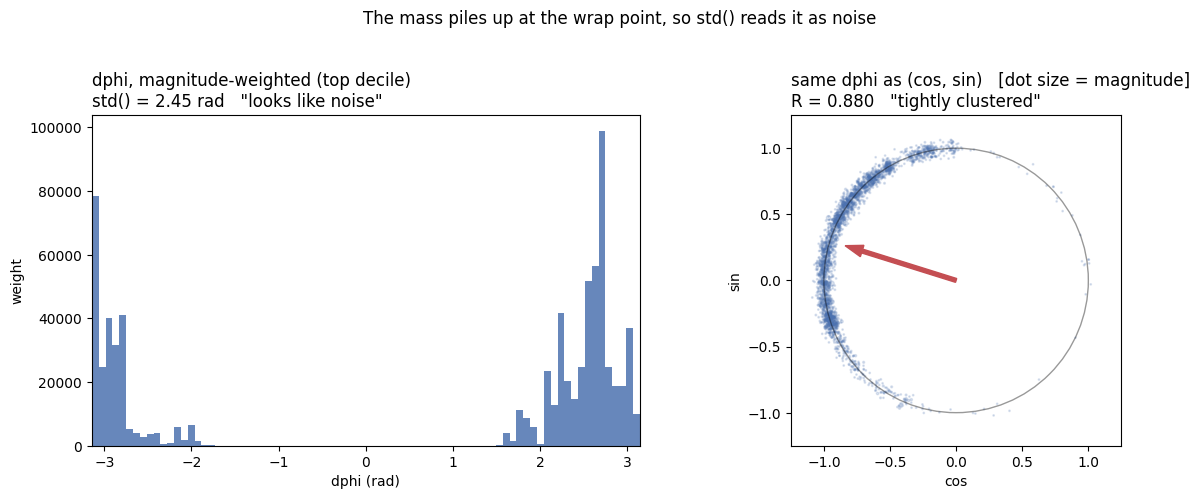

In [7]:
# what the old test and the new test see, on the SAME data
X = get(0)
m = energy_mask(X, 0.10); pair = m[1:] & m[:-1]
d_top = dphi(X)[:, pair, :].ravel()
w_top = pair_weight(X)[:, pair, :].ravel()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

ax = axes[0]
ax.hist(d_top, bins=80, range=(-np.pi, np.pi), weights=w_top, color='#4C72B0', alpha=.85)
ax.set_title(f'dphi, magnitude-weighted (top decile)\nstd() = {d_top.std():.2f} rad   "looks like noise"', loc='left')
ax.set_xlabel('dphi (rad)'); ax.set_ylabel('weight'); ax.set_xlim(-np.pi, np.pi)

ax = axes[1]
sub = slice(None, None, 7)
ds_, ws_ = d_top[sub], w_top[sub]
rr = 1 + 0.03 * np.random.default_rng(1).standard_normal(ds_.size)   # jitter for visibility only
ax.scatter(rr * np.cos(ds_), rr * np.sin(ds_), s=1 + 14 * ws_ / ws_.max(),
           alpha=.18, color='#4C72B0')
mu = (w_top * np.exp(1j * d_top)).sum() / w_top.sum()
ax.arrow(0, 0, mu.real, mu.imag, width=.03, color='#C44E52',
         length_includes_head=True, zorder=5)
ax.add_artist(plt.Circle((0, 0), 1, fill=False, lw=1, color='k', alpha=.4))
ax.set_aspect('equal'); ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25)
ax.set_title(f'same dphi as (cos, sin)   [dot size = magnitude]\nR = {abs(mu):.3f}   "tightly clustered"', loc='left')
ax.set_xlabel('cos'); ax.set_ylabel('sin')

fig.suptitle('The mass piles up at the wrap point, so std() reads it as noise', y=1.03)
fig.tight_layout()

That's the entire illusion. The distribution is concentrated near $\pm\pi$ — the
wrap point — so it splits across both edges of the histogram and `std` reports the
noise value. On the circle it's plainly a tight cluster with a long resultant.

## 7 Test 2 — so should we fit the ramp and subtract it?

That's what notebook 57 tried, and it made things *much worse*
(Spearman $-0.526 \to -0.136$). If the ramp is real, why did removing it fail?

Compare three treatments by **across-laser agreement** — how similar the 100
lasers' phases are within a single sample:

1. **raw phase** — no correction
2. **deramped** — fit a constant delay *per laser* and divide it out
3. **group delay** — difference along `f`, which cancels any ramp without ever
   estimating one

Note the asymmetry: (2) *estimates* the ramp, (3) *cancels* it structurally.

In [8]:
def deramp(X, mask):
    """Fit and remove a magnitude-weighted constant delay per (laser, channel).

    The best-fit constant is the weighted circular MEAN of dphi -- the angle of
    the resultant vector -- which again needs no unwrapping.
    """
    d, w = dphi(X), pair_weight(X)
    pair = mask[1:] & mask[:-1]
    b = np.angle((w[:, pair, :] * np.exp(1j * d[:, pair, :])).sum(axis=1, keepdims=True))  # rad/bin
    k = np.arange(X.shape[1])[None, :, None]
    return X * np.exp(-1j * b * k)

recs = []
for i in range(8):
    X = get(i)
    m = energy_mask(X, 0.10); pair = m[1:] & m[:-1]
    w = np.abs(X)[:, m, :]
    R_raw = wR(np.angle(X[:, m, :]),            w, axis=0).mean()
    R_der = wR(np.angle(deramp(X, m)[:, m, :]), w, axis=0).mean()
    zg = (X[:, 1:, :] * np.conj(X[:, :-1, :]))[:, pair, :]
    wg = pair_weight(X)[:, pair, :]
    R_gd = wR(np.angle(zg), wg, axis=0).mean()
    recs.append((R_raw, R_der, R_gd))

A = np.array(recs)
print(f'{"sample":>8} {"raw":>8} {"deramped":>9} {"groupdel":>9}')
for i, r in enumerate(A):
    print(f'{i:8d} {r[0]:8.4f} {r[1]:9.4f} {r[2]:9.4f}')
print(f'{"MEAN":>8} {A[:,0].mean():8.4f} {A[:,1].mean():9.4f} {A[:,2].mean():9.4f}')

  sample      raw  deramped  groupdel
       0   0.4101    0.1101    0.9943
       1   0.3981    0.0905    0.9881
       2   0.4032    0.0964    0.9938
       3   0.3818    0.1105    0.9933
       4   0.4044    0.1013    0.9940
       5   0.3876    0.0991    0.9955
       6   0.3954    0.1138    0.9898
       7   0.4209    0.0954    0.9951
    MEAN   0.4002    0.1021    0.9930


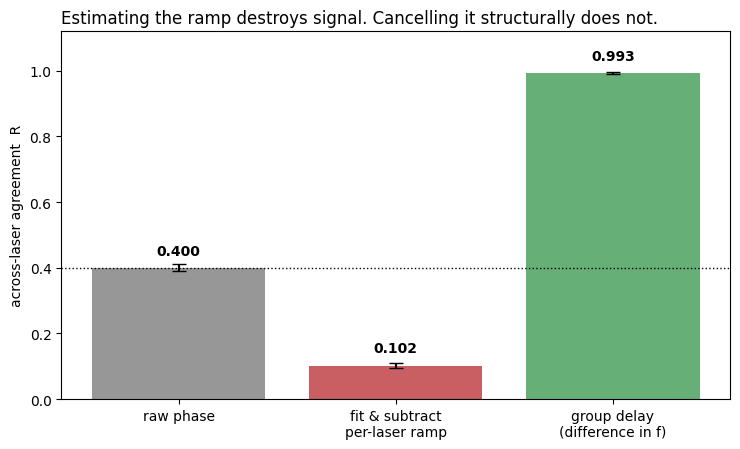

In [9]:
labels = ['raw phase', 'fit & subtract\nper-laser ramp', 'group delay\n(difference in f)']
means, sds = A.mean(axis=0), A.std(axis=0)
colors = ['#8C8C8C', '#C44E52', '#55A868']

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.bar(labels, means, yerr=sds, color=colors, alpha=.9, capsize=5)
for i, v in enumerate(means):
    ax.text(i, v + .04, f'{v:.3f}', ha='center', fontweight='bold')
ax.set_ylabel('across-laser agreement  R'); ax.set_ylim(0, 1.12)
ax.axhline(A[:, 0].mean(), ls=':', c='k', lw=1)
ax.set_title('Estimating the ramp destroys signal. Cancelling it structurally does not.', loc='left')
fig.tight_layout()

| treatment | across-laser $R$ |
|---|---|
| raw phase | 0.400 |
| fit & subtract per-laser ramp | **0.102** ← much worse |
| group delay | **0.993** ← much better |

This is the key result, and it resolves the apparent contradiction between
notebooks 57 and 68 with a single mechanism:

> **The ramp is real and largely *shared across lasers*.** That shared component is
> part of what makes the lasers agree with each other. Fitting a ramp *per laser*
> absorbs real per-laser signal into the fit and throws it away — so agreement
> collapses. Differencing along `f` cancels the ramp without ever estimating it,
> keeping everything else intact.

nb57 failed not because there was no ramp to remove, but because *estimating* it
per-laser is the wrong operation. nb68 succeeded because differencing is the right
one. Same physics, opposite outcomes.

## 8 What is the ramp, physically?

Convert the fitted per-bin slope to a delay: $\tau = -b / (2\pi\,\Delta f)$.

In [10]:
print(f'{"sample":>7} {"spk":>4} {"b (rad/bin)":>12} {"tau (ms)":>10} {"R":>7}')
taus = []
for i in range(12):
    X = get(i)
    m = energy_mask(X, 0.10); pair = m[1:] & m[:-1]
    dd, ww = dphi(X)[:, pair, :].ravel(), pair_weight(X)[:, pair, :].ravel()
    mu = (ww * np.exp(1j * dd)).sum() / ww.sum()
    b = np.angle(mu)
    tau_ms = -b / (2 * np.pi * DF) * 1e3
    taus.append(tau_ms)
    print(f'{i:7d} {meta[i]["speaker"]:4d} {b:12.4f} {tau_ms:10.1f} {abs(mu):7.3f}')

print(f'\nspread across samples: {np.std(taus):.1f} ms  (mean {np.mean(taus):.0f} ms)')

 sample  spk  b (rad/bin)   tau (ms)       R
      0    2       2.8383     -587.3   0.880
      1    3       2.9418     -608.7   0.898
      2    4       3.0141     -623.6   0.902
      3    5       2.9714     -614.8   0.895
      4    6       2.9477     -609.9   0.836
      5    7       2.8499     -589.7   0.864
      6    8       2.7537     -569.8   0.863
      7    1       2.8963     -599.3   0.898
      8    2       2.8422     -588.1   0.882
      9    3       2.9447     -609.3   0.895
     10    4       3.0203     -624.9   0.909
     11    5       2.9943     -619.5   0.893

spread across samples: 16.3 ms  (mean -604 ms)


$\tau \approx -600$ ms, and it is **consistent across all 8 speakers** (spread only
16 ms).

That is far too large and far too stable to be trigger jitter, which is order 1 ms
and independent per recording. So what is it?

### The obvious guess — and why it's wrong

The tempting answer is the **chirp's own sweep timing**: the excitation is a 1.0 s
logarithmic sweep, so each frequency is emitted at a different moment, which sounds
delay-like.

We don't have to guess. The source `.wav` is on disk, so run the *identical*
measurement on it. If the chirp were the source of the ramp, its own phase would
have to carry that ramp.

In [11]:
import scipy.io.wavfile as wav

fs, a = wav.read(REPO / 'data/audio/chirp_50_1000_1.0sec/audio.wav')
a = a.astype(np.float64); a /= np.abs(a).max()

Z = np.fft.rfft(a)
fz = np.fft.rfftfreq(a.size, 1 / fs)
band = (fz >= 50) & (fz <= 1000)
Zb = Z[band]

dc = np.angle(Zb[1:] * np.conj(Zb[:-1]))            # same dphi, on the chirp
wc = np.abs(Zb[1:]) * np.abs(Zb[:-1])
R_chirp = abs((wc * np.exp(1j * dc)).sum() / wc.sum())

# how well does a straight line describe the chirp's phase at all?
u = np.unwrap(np.angle(Zb))
resid1 = u - np.polyval(np.polyfit(fz[band], u, 1), fz[band])
resid2 = u - np.polyval(np.polyfit(fz[band], u, 2), fz[band])

print(f'chirp: {a.size} samples @ {fs} Hz = {a.size/fs:.2f} s, {band.sum()} bins in 50-1000 Hz\n')
print(f'  R of dphi across freq  = {R_chirp:.4f}     <- the DATA gave 0.90')
print(f'  linear    fit residual = {resid1.std():8.1f} rad')
print(f'  quadratic fit residual = {resid2.std():8.1f} rad')

chirp: 52920 samples @ 44100 Hz = 1.20 s, 1141 bins in 50-1000 Hz

  R of dphi across freq  = 0.2008     <- the DATA gave 0.90
  linear    fit residual =    129.4 rad
  quadratic fit residual =    127.9 rad


**The chirp's own phase gives $R = 0.20$ — indistinguishable from the noise floor.**
A straight line leaves ~129 rad of residual, and a quadratic barely improves on it.

The chirp's phase is *strongly nonlinear in f*, which is exactly right for a
logarithmic sweep: instantaneous frequency is $f(t) = f_0 (f_1/f_0)^{t/T}$, and the
stationary-phase result is logarithmic in $f$ — not linear, not even polynomial.

So the excitation is **ruled out** as the source of the ramp. The measured spectra
are *more* linear-in-f ($R = 0.90$) than the signal that produced them ($R = 0.20$).
Whatever creates the ramp is downstream of the speaker.

### What it actually is: the time origin

The rFFT measures phase **relative to $t = 0$** — the first sample of the array. If
the signal you care about does not *start* at sample 0, the transform reports that
displacement as phase.

Our capture is 3250 samples at 2500 fps = 1.30 s, and the response energy sits near
the **middle** of that window, not at its start. The FFT cannot know that; it
reports "this component is offset from my clock's zero by ~600 ms," which by the
shift theorem is a linear ramp.

Check the slope: $b \approx 2.84$ rad/bin, close to $\pi = 3.14$. A slope of exactly
$\pi$ means the phase flips sign on every consecutive bin — the signature of a shift
by **half the record** — and half of 1.30 s is **650 ms**, against the measured
**604 ms**.

This is a **bookkeeping artifact of where we cut the window**, not a property of the
box. Slide the same waveform to a different position in the array: every magnitude
is unchanged, the entire phase ramp changes. And it is laser-shared for a simple
reason — all 100 lasers are cut from the *same* capture window, so they inherit the
same offset.

## 9 The full decomposition — and why the terms add

### Why they add at all

Everything between the `.wav` file and the laser is a chain of **linear
time-invariant** stages. Cascaded LTI systems **multiply** in the frequency domain
(the convolution theorem), so for laser $l$, speaker $s$, sample $n$:

$$Z_{l,s,n}(f) \;=\; \underbrace{A(f)}_{\text{chirp}}\;\cdot\;
                     \underbrace{S_s(f)}_{\text{speaker path}}\;\cdot\;
                     \underbrace{H_l(f)}_{\text{box}}\;\cdot\;
                     \underbrace{e^{-2\pi i f \tau_n}}_{\text{timing}}\;+\;N(f)$$

Take $\angle$ of a product and multiplication becomes addition:

$$\boxed{\;\theta_{l,s,n}(f) \;=\; \theta_{\text{audio}}(f) \;+\; \theta_{\text{speaker}}(s,f)
   \;+\; \theta_{\text{laser}}(l,f) \;-\; 2\pi f\,\tau_n \;+\; \theta_{\text{noise}}\;}$$

That is the whole justification. It is not an assumption about phase — it follows
from each stage being LTI.

**Where it breaks**, stated plainly:
- *Nonlinearity* — speaker distortion at high drive violates it.
- *Additive noise* — $N(f)$ adds to $Z$, **not** to $\theta$. In low-magnitude bins
  the phase is then arbitrary and the decomposition is meaningless. This is exactly
  why every statistic here is masked to the top decile and magnitude-weighted.
- *Time-invariance during the record* — drift within a capture is not modelled.

So: a good model in the high-energy bins, a bad one in the noise floor.

### What each factor is

Each symbol is the **frequency response** of one physical stage — a complex number
per frequency, whose magnitude says "how much this stage scales $f$" and whose angle
says "how much it delays $f$."

| symbol | name | definition | measured how |
|---|---|---|---|
| $A(f)$ | **excitation spectrum** | the rFFT of the chirp `.wav` itself: $A(f) = \mathcal{F}\{a(t)\}$, where $a(t)$ is the 1.0 s log sweep. Purely a property of the file we generated. | directly — we did this in §8 |
| $S_s(f)$ | **speaker-to-box transfer function** | everything between the digital sample and the box wall for speaker $s$: amplifier, membrane response, and the air path (distance $d_s$, angle of incidence). Contains a bulk propagation delay $d_s/c$ **plus** the membrane's own frequency-dependent lag. | not directly; only its *effect*, via same- vs different-speaker comparison below |
| $H_l(f)$ | **box transfer function at laser $l$** | **the thing we want.** $H_l(f) = X_l(f)/F(f)$ — the wall's displacement at point $l$ per unit acoustic forcing. From the modal expansion $H_l(f)=\sum_r \phi_r(l)\phi_r/(\omega_r^2-\omega^2+2i\zeta_r\omega_r\omega)$, so its phase flips by $\pi$ through each resonance and encodes the mode shape $\phi_r(l)$ — which is what changes when a cube moves. | never in isolation; only relative to a reference laser |
| $e^{-2\pi i f\tau_n}$ | **timing phasor** | a pure delay $\tau_n$ for recording $n$: the §8 time-origin offset (~604 ms, shared) plus trigger jitter (~1 ms, random). Magnitude exactly 1 — it *only* moves phase. | §8, as the fitted slope |
| $N(f)$ | **additive noise** | sensor noise, AC hum, air currents. Enters as a **sum**, not a product, which is why it is the one term that does not become additive in phase. | via the phase-randomized null |

Note the asymmetry: the first four multiply (so their phases add), while $N$ adds.
That is precisely why the decomposition holds only where $|Z| \gg |N|$.

### The terms, and what kills each

| term | what it is | shape in $f$ | varies with | **killed by** |
|---|---|---|---|---|
| $\theta_{\text{audio}}(f) = \angle A(f)$ | the `.wav` file itself — a log sweep emits each frequency at a different moment | **nonlinear** ($R=0.20$, measured) | nothing — identical every recording | **laser referencing** (not group delay — it is not linear) |
| $\theta_{\text{speaker}}(s,f) = \angle S_s(f)$ | speaker $s$ sits at its own distance/angle, so its wave arrives with its own delay and room path | delay part linear, membrane/room part not | speaker only | **laser referencing**; also cancels if you only ever compare within one speaker |
| $\theta_{\text{laser}}(l,f) = \angle H_l(f)$ | **the box response — the signal we want** | modal: $\pi$ flips at resonances | **laser** (and the objects inside) | **nothing — keep it.** Referencing keeps it *relative* to the ref laser |
| $-2\pi f\,\tau_n$ | time origin (§8) + trigger jitter, both pure delays | **exactly linear** | sample | **group delay** *or* **laser referencing** — either works, it is both linear and laser-constant |
| $\theta_{\text{noise}}$ | AC hum, membrane state, sensor noise | none — uniform | sample, laser, bin | **no gauge can.** Only the energy mask + magnitude weighting, which down-weight where it dominates |

Three things worth reading off this table.

**Only one row is signal.** Everything else is nuisance, and every nuisance except
noise is laser-constant — which is why laser referencing is the more complete gauge.

**Your $\theta_{\text{jitter}}$ splits in two.** Trigger jitter (audio fired
non-blocking with no hardware sync) is a *delay*, so it is linear in $f$ and lands
in row 4 — removable. Air conditioning, membrane state and sensor noise are *not* a
delay, have no shape in $f$, and are removable by no gauge at all; they are row 5.
Worth keeping apart because one is fixable and one is not.

**Yes — $\theta_{\text{laser}}$ is the signal.** But it is only *approximately*
separable: $H_l(f)$ is the box's transfer function, and placing a cube changes the
whole modal structure rather than adding an independent per-laser term (see
`docs/physics_and_architecture.md` §2 — matrix inversion is not linear). The
decomposition separates *excitation from response*; it does not claim the response
itself decomposes over objects.

## 10 The two gauges, as equations

### What the column headings actually mean

**"Shape in $f$"** — yes, this is what $d\phi$ probes. Define the difference along
the **frequency** axis:

$$d\phi_l(f) \;=\; \angle\!\big(z_l(f{+}\Delta f)\,\overline{z_l(f)}\big) \;=\; \theta_l(f{+}\Delta f) - \theta_l(f)$$

A term is *linear in $f$* exactly when its contribution to $d\phi$ is a **constant**
(independent of $f$). That is what §6 measured: $R = 0.90$ means "nearly constant",
hence "nearly linear".

**"Laser-shared"** — the difference along the **laser** axis:

$$\Delta_{l,l'}(f) \;=\; \theta_l(f) - \theta_{l'}(f)$$

A term is *laser-shared* exactly when it cancels from $\Delta_{l,l'}$, i.e. when it
does not depend on $l$. Note this is a different axis from $d\phi$ — which is the
whole reason the two gauges remove different things.

### Gauge 1 — group delay (difference along $f$)

$$G_l(f) \;=\; \frac{z_l(f{+}\Delta f)\,\overline{z_l(f)}}{\big|z_l(f{+}\Delta f)\big|\,\big|z_l(f)\big|}
\;=\; e^{\,i\,d\phi_l(f)}$$

Substituting the decomposition, the delay term contributes
$-2\pi(f{+}\Delta f)\tau_n + 2\pi f \tau_n = -2\pi\,\Delta f\,\tau_n$ — a **constant,
independent of $f$**. So the sample's unknown $\tau_n$ becomes one global rotation
shared by every bin, which the resultant $R$ is invariant to.

$$G_l(f) \;\propto\; \exp i\big[\underbrace{\Delta\theta_{\text{audio}} + \Delta\theta_{\text{speaker}}}_{\textbf{survives}} + \underbrace{\Delta\theta_{\text{laser}}}_{\text{signal}}\big]$$

**Kills:** anything linear in $f$ — the time origin and trigger jitter (row 4).
**Leaves:** the chirp's nonlinear phase (row 1) and the speaker's membrane/room path
(row 2), because neither is a straight line.

### Gauge 2 — laser referencing (difference along $l$)

$$R_l(f) \;=\; \frac{z_l(f)\,\overline{z_{\text{ref}}(f)}}{\big|z_l(f)\big|\,\big|z_{\text{ref}}(f)\big|}
\;=\; e^{\,i\,[\theta_l(f)\,-\,\theta_{\text{ref}}(f)]},
\qquad z_{\text{ref}}(f) = \sum_{l'} z_{l'}(f)$$

Now substitute. Every term that does **not** carry an $l$ index appears identically
in $\theta_l$ and $\theta_{\text{ref}}$, so it subtracts to zero:

$$\theta_l - \theta_{\text{ref}} = \cancel{\theta_{\text{audio}}} + \cancel{\theta_{\text{speaker}}} + \cancel{(-2\pi f\tau_n)} + \big[\theta_{\text{laser}}(l,f) - \theta_{\text{laser}}(\text{ref},f)\big]$$

**This holds regardless of shape in $f$.** It is an algebraic identity, not an
approximation — which is why it removes the chirp's nonlinear phase that group delay
cannot touch.

**Kills:** rows 1, 2 and 4 — every laser-constant term, any shape.
**Leaves:** only $\theta_{\text{laser}}$, measured relative to the reference laser.

### Which gauge kills which term

| term | shape in $f$ | constant in $l$? | group delay | laser referencing |
|---|---|---|---|---|
| $\theta_{\text{audio}}$ | nonlinear | yes | ✗ survives | **✓ killed** |
| $\theta_{\text{speaker}}$ | partly linear | yes | ~ partly | **✓ killed** |
| $\theta_{\text{laser}}$ | modal | **no** | ✓ kept (differenced) | ✓ kept (relative) |
| $-2\pi f\tau_n$ | exactly linear | yes | **✓ killed** | **✓ killed** |
| $\theta_{\text{noise}}$ | none | no | ✗ | ✗ — mask instead |

Group delay is **shape**-selective; referencing is **index**-selective. Referencing
dominates on paper — it kills strictly more — but group delay has one advantage:
it needs no reference laser, so it cannot be spoiled by a reference that happens to
sit on a nodal line. Which is why both stay in the stage-B ablation rather than one
being declared the winner here.

The one cost of referencing is that the signal becomes relative: a global
per-frequency rotation is unrecoverable. For imaging that is fine — position
information lives in how lasers differ from each other, not in their common phase.

## 11 Can we split the box from the object?

The natural next question: §9 factored the *excitation chain*, but $H_l(f)$ is still
one lump. Can it split into "the empty box" times "what the cube did"?

$$Z_{l,s,n,p}(f) \;\stackrel{?}{=}\; A(f)\,S_s(f)\,\underbrace{H_{l,\text{empty}}(f)\,G_{l,p}(f)}_{H_{l,p}(f)}\,T_n(f) \;+\; N(f)$$

### Why this is not free, unlike the other factors

$A$, $S_s$ and $T_n$ multiply because they are **separate stages in a cascade** —
signal passes through the speaker, then the air, then reaches the box. Cascaded LTI
systems multiply; that is the convolution theorem.

The empty box and the cube are **not two stages**. They are two parts of *one*
coupled structure, solved simultaneously. There is no intermediate signal that is
"the empty-box response" before the cube filters it. Formally,

$$H = \big(K + i\omega C - \omega^2 M\big)^{-1}, \qquad M \to M + \delta M_p$$

The perturbation $\delta M_p$ is additive, but $H$ is the **inverse** of that sum,
and inversion does not factor. Writing $A_0 = K + i\omega C - \omega^2 M$ and
$E_p = -\omega^2\delta M_p$, the Neumann expansion gives

$$H_p \;=\; A_0^{-1} \;-\; A_0^{-1}E_pA_0^{-1} \;+\; A_0^{-1}E_pA_0^{-1}E_pA_0^{-1} \;-\;\cdots$$

so the ratio $G_{l,p} \equiv H_{l,p}/H_{l,\text{empty}}$ exists by *definition*, but to
first order

$$G_{l,p} \;\approx\; 1 - \frac{\big[A_0^{-1}E_pA_0^{-1}\big]_l}{\big[A_0^{-1}\big]_l}$$

which still depends on $A_0$ — the empty box. $G$ is **not a property of the cube
alone**, and the expansion converges only for small $\|A_0^{-1}E_p\|$. A metal cube
visibly moves resonances, so it is not small.

### The test

If the factorization is useful, dividing out the empty box should leave something
that **tracks the cube's position**. So: fix one speaker (removing $S_s$ as a
confound entirely), and ask whether feature similarity falls off with the distance
between two samples' centres of mass.

Every position in this layout is captured once per speaker, so within one speaker
there are no exact repeats — but the 70 positions give 2415 pairs spanning
50–1050 px, which is ample.

In [12]:
from scipy.stats import spearmanr

SPK = 1                                   # one speaker only: S_s is then a constant
LOG_EPS = 1e-3                            # matches dataset.LOG_EPS

def com_of(d):
    """Centre of mass of the (single) object, or None if absent/invalid."""
    try:                       return np.array(d['coms'][0][0], dtype=float)
    except Exception:          return None

# empty-box reference for this speaker
eb_rows = [i for i, d in enumerate(meta)
           if d.get('layout') == 'empty-box' and d['speaker'] == SPK]
E = np.mean([get(j) for j in eb_rows], axis=0)

rows = [(i, com_of(d)) for i, d in enumerate(meta)
        if d.get('layout') == 'purple-cube' and d['speaker'] == SPK]
rows = [r for r in rows if r[1] is not None and (r[1] >= 0).all()]

MASK = energy_mask(get(rows[0][0]), 0.10)
logE = np.log(np.abs(E) + LOG_EPS)[:, MASK, :].ravel()

def features(i):
    """Four candidate features for one sample, each flattened to a vector."""
    Z  = get(i)
    g  = (Z / (E + 1e-12))[:, MASK, :].ravel()               # complex divide
    z  = Z[:, MASK, :].ravel()                               # raw complex
    lm = np.log(np.abs(Z) + LOG_EPS)[:, MASK, :].ravel()     # log-magnitude
    lg = lm - logE                                           # log-mag minus empty box
    return g, z, lm - lm.mean(), lg - lg.mean()

F = {i: features(i) for i, _ in rows}

def cos_sim(a, b):
    return float(np.abs(np.vdot(a, b)) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-20))

NAMES = ['G = Z/empty', 'raw Z', 'logmag', 'logmag - empty']
dist, sims = [], [[] for _ in NAMES]
for a in range(len(rows)):
    ia, ca = rows[a]
    for b in range(a + 1, len(rows)):
        ib, cb = rows[b]
        dist.append(np.linalg.norm(ca - cb))
        for t in range(len(NAMES)):
            sims[t].append(cos_sim(F[ia][t], F[ib][t]))

dist = np.array(dist); sims = [np.array(s) for s in sims]
print(f'speaker {SPK}: {len(rows)} samples, {len(dist)} pairs, '
      f'{len(eb_rows)} empty-box refs, COM dist {dist.min():.0f}-{dist.max():.0f} px\n')
print(f'{"feature":>18} {"rho":>8}   (more negative = tracks position better)')
for n, s in zip(NAMES, sims):
    print(f'{n:>18} {spearmanr(dist, s).statistic:+8.4f}')

speaker 1: 70 samples, 2415 pairs, 3 empty-box refs, COM dist 50-1051 px

           feature      rho   (more negative = tracks position better)
       G = Z/empty  -0.3111
             raw Z  -0.2177
            logmag  -0.4413
    logmag - empty  -0.4756


 COM dist (px)      n       G = Z/empty            raw Z           logmag   logmag - empty
        45-120    133            0.8292           0.9276           0.9650           0.7335
       120-250    362            0.7775           0.9002           0.9523           0.6432
       250-450    781            0.7525           0.8860           0.9412           0.5740
       450-700    806            0.7300           0.8743           0.9317           0.4919
      700-1100    333            0.7204           0.8905           0.9210           0.4180


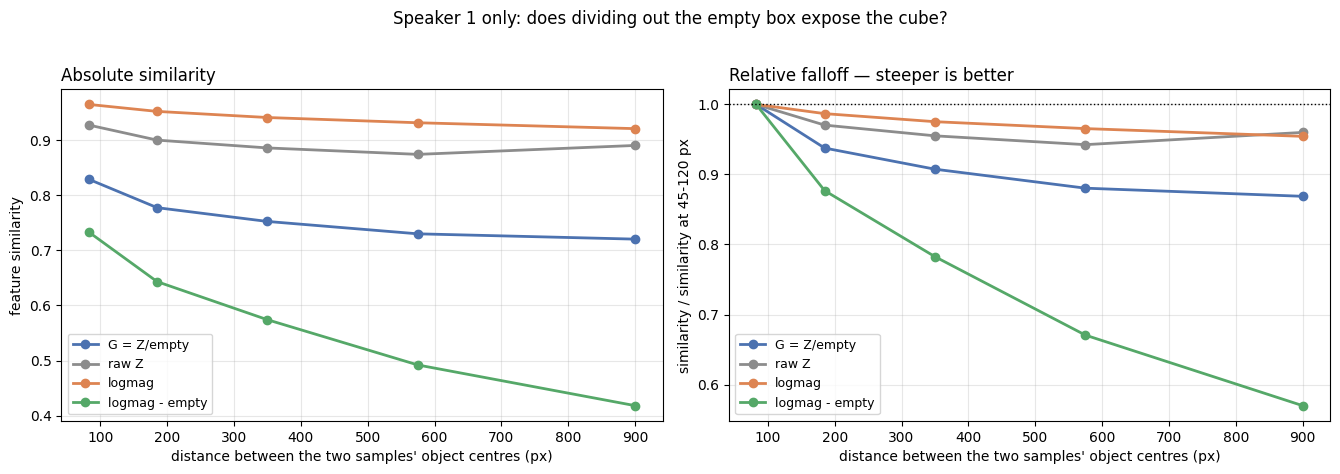

In [13]:
BINS = [(45, 120), (120, 250), (250, 450), (450, 700), (700, 1100)]
centres = [(lo + hi) / 2 for lo, hi in BINS]

print(f'{"COM dist (px)":>14} {"n":>6}  ' + ' '.join(f'{n:>16}' for n in NAMES))
curves = [[] for _ in NAMES]
for lo, hi in BINS:
    sel = (dist >= lo) & (dist < hi)
    for t in range(len(NAMES)):
        curves[t].append(sims[t][sel].mean())
    print(f'{f"{lo}-{hi}":>14} {sel.sum():6d}  '
          + ' '.join(f'{sims[t][sel].mean():16.4f}' for t in range(len(NAMES))))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
colors = ['#4C72B0', '#8C8C8C', '#DD8452', '#55A868']

ax = axes[0]
for n, c, col in zip(NAMES, curves, colors):
    ax.plot(centres, c, 'o-', color=col, label=n, lw=2)
ax.set_xlabel('distance between the two samples\' object centres (px)')
ax.set_ylabel('feature similarity')
ax.set_title('Absolute similarity', loc='left')
ax.legend(fontsize=9); ax.grid(alpha=.3)

# same curves, each normalized to its own first bin -- isolates the FALLOFF,
# which is what "tracks position" actually means
ax = axes[1]
for n, c, col in zip(NAMES, curves, colors):
    ax.plot(centres, np.array(c) / c[0], 'o-', color=col, label=n, lw=2)
ax.set_xlabel('distance between the two samples\' object centres (px)')
ax.set_ylabel('similarity / similarity at 45-120 px')
ax.set_title('Relative falloff — steeper is better', loc='left')
ax.axhline(1.0, ls=':', c='k', lw=1); ax.grid(alpha=.3); ax.legend(fontsize=9)

fig.suptitle(f'Speaker {SPK} only: does dividing out the empty box expose the cube?', y=1.02)
fig.tight_layout()

### Verdict: the factorization works, in the log domain

| feature | $\rho$ | sim @ 45–120 px | @ 700–1100 px | **falloff** |
|---|---|---|---|---|
| raw $Z$ | −0.218 | 0.928 | 0.891 | 0.04 |
| $G = Z/\text{empty}$ (complex) | −0.311 | 0.829 | 0.720 | 0.11 |
| $\log$mag | −0.441 | 0.965 | 0.921 | 0.04 |
| **$\log$mag − empty** | **−0.476** | **0.734** | **0.418** | **0.32** |

Every feature decreases monotonically with COM distance, which is the minimum the
physics demands. But the *falloff* column is the real result: raw log-magnitude sits
at 0.92–0.97 no matter where the cube is, because almost all of its content is the
box and the speaker, with the cube as a faint perturbation on top. Subtracting the
empty box removes that common mass, and what remains swings 0.73 → 0.42 — an **8×
larger dynamic range**.

So the prediction that follows from your factorization — *divide out
$H_{\text{empty}}$ and what remains tracks the cube* — is confirmed. It is the best
feature tested here, and it independently reproduces notebook 68's finding that
empty-box subtraction was the winning magnitude recipe ($\rho = .486$).

**Two honest qualifications.**

*Log beats complex.* `logmag − empty` (−0.476) clearly beats the complex divide
$Z/E$ (−0.311). Complex division amplifies noise wherever $|E|$ is small, and the
phase of the ratio still carries the uncancelled $T_n$. Subtraction in the log
domain touches magnitude only — which is exactly what `dataset.subtract_empty_box_ref`
already does.

*$G_{l,p}$ is not purely a function of $p$.* Held to one speaker it behaves well.
Across speakers it does not: two recordings of the **same physical scene** from
different speakers reach only $0.437$ similarity in $G$, where a cube-only term would
give $\approx 1$. That residual speaker dependence is precisely the $A_0$ in the
Neumann expansion above.

**Bottom line.** $H_{l,p} = H_{l,\text{empty}}\cdot G_{l,p}$ is a sound *engineering*
approximation **within a speaker** — which is how the pipeline already uses it — but
it is not exact physics, and a cube-only term should not be expected to transfer
across speakers. This is the same non-separability that rules out synthesising
multi-object data from single-object samples (`docs/physics_and_architecture.md` §2):
$H_{AB} \neq f(H_A, H_B)$, because objects interact *through* the box.

In [14]:
import collections

# Is theta_speaker really a SEPARATE, per-speaker term? Test it.
#
# After laser referencing, theta_audio and the delay are gone. If a distinct
# per-speaker term also exists, then two recordings from the SAME speaker should
# agree MORE than two from DIFFERENT speakers. If speaker made no separable
# contribution, the two numbers would be equal.

by_spk = collections.defaultdict(list)
for i, dct in enumerate(meta[:400]):
    by_spk[dct['speaker']].append(i)

def ref_phase(i, mask):
    """Laser-referenced phasor + magnitude weight, restricted to `mask`."""
    X = get(i)
    z_ref = X.sum(axis=0, keepdims=True)
    r = X * np.conj(z_ref) / (np.abs(X) * np.abs(z_ref) + 1e-20)
    return r[:, mask, :], np.abs(X)[:, mask, :]

def agree(i, j, mask):
    """Weighted circular agreement between two recordings' referenced phase."""
    a, wa = ref_phase(i, mask)
    b, _  = ref_phase(j, mask)
    rel = a * np.conj(b)                      # phase difference, on the circle
    return float(np.abs((wa * rel).sum() / wa.sum()))

M = energy_mask(get(0), 0.10)
spks = sorted(by_spk)

same = [agree(by_spk[s][0], by_spk[s][1], M) for s in spks if len(by_spk[s]) >= 2]
diff = [agree(by_spk[a][0], by_spk[b][0], M) for a, b in zip(spks, spks[1:])]

print('Laser-referenced phase, agreement between two recordings:')
print(f'  SAME speaker      R = {np.mean(same):.4f}   (n={len(same)})')
print(f'  DIFFERENT speaker R = {np.mean(diff):.4f}   (n={len(diff)})')
print(f'\n  gap = {np.mean(same) - np.mean(diff):.4f}')
print('  -> a separable per-speaker term exists; if it did not, these would match.')

Laser-referenced phase, agreement between two recordings:
  SAME speaker      R = 0.9932   (n=8)
  DIFFERENT speaker R = 0.9113   (n=7)

  gap = 0.0819
  -> a separable per-speaker term exists; if it did not, these would match.


## 12 What to take away

**About the physics**

1. There *is* a large linear-in-`f` phase ramp ($R = 0.90$ vs null $0.21$).
2. It is **not** the chirp. The excitation's own phase is strongly nonlinear
   ($R = 0.20$), so the data is *more* linear than the signal that produced it.
   The ramp is a **time-origin artifact**: slope $\approx \pi$ rad/bin, i.e. a shift
   of half the 1.30 s record (650 ms vs measured 604 ms).
3. It is **shared across lasers** — every laser comes from the same capture window —
   so it partly *creates* the agreement between them rather than obscuring it.
4. Therefore: **cancel it structurally, never fit it.** Group delay (difference
   along `f`) takes across-laser agreement from 0.40 to 0.993. A per-laser fit
   drops it to 0.10.
5. The nuisances have **different shapes and different index-dependence**, so they
   need different gauges (§10). Group delay is shape-selective — it kills terms
   linear in $f$. Laser referencing is index-selective — it kills anything constant
   in $l$, whatever its shape, including the chirp's nonlinear phase. Complementary,
   not redundant.
6. **The box/object split works in the log domain but is not exact** (§11).
   `logmag - empty_box` has by far the steepest falloff with COM distance
   ($\rho=-0.476$, similarity 0.73 → 0.42) — 8× the dynamic range of raw
   log-magnitude. But $G_{l,p}$ retains a speaker dependence it would not have if
   the factorization were exact, so treat it as an engineering approximation valid
   *within* a speaker.

**About the method** — this is the part worth generalizing:

- **Never use `mean`/`std` on angles.** Use $(\cos\phi, \sin\phi)$ and the resultant
  $R$. Wrapping makes tight clusters look like noise, which is precisely the error
  made here.
- **Always weight by magnitude and mask to high-energy bins.** ~90% of bins are
  noise floor and will swamp an unweighted statistic. This is not a detail: the
  additive-phase model in §9 is only valid where $|Z| \gg |N|$.
- **Always run a null.** "$R = 0.87$" is meaningless until you know the null gives
  $0.17$. The original test had no null, so a value forced to be ~1.00 by
  construction read as a substantive finding.
- **Check whether your statistic can even move.** $R$ is invariant to a global
  rotation, so `R_res/R_raw` is *identically* 1 — the original test had zero power
  and could never have detected the effect it was looking for.
- **Measure the explanation, don't just tell a story about it.** The "it's the sweep
  timing" account of the ramp was plausible, fit the magnitude of the effect, and
  was wrong — one FFT of the source `.wav` refuted it.
- **Hold confounds fixed rather than averaging over them, and use the continuous
  variable.** §11's first attempt compared samples by `position_id` while pooling
  speakers, and produced a *negative* separation — an artifact. Restricting to one
  speaker and binning by actual COM distance turned the same data into a clean
  monotonic result.

**Still open**

- The across-sample repeat test (which would isolate trigger jitter from the shared
  time-origin ramp) did not run — no `(speaker, position, layout)` group in this
  shard has ≥3 samples.
- `eta^2(speaker) = 0.297` from the earlier slope-variance decomposition was
  computed with the same unweighted wrapped-angle slopes invalidated above. It is
  marked provisional in `src/model/normalizations.py` and should be redone with
  circular statistics.
- The residual 46 ms between the measured 604 ms and the exact half-record 650 ms
  is unexplained. Candidates: the 0.1 s silence pads on the chirp, group delay
  through the speaker, or the `sosfiltfilt` + Hann window in `get_clean_shifts`.
- §11 ran on speaker 1 only. The other seven are one loop away and would show
  whether $\rho = -0.476$ is stable.
- None of this establishes that phase *helps the model* — only that it is
  recoverable and self-consistent. That is a training question, and the stage-A /
  stage-B ablation grid in notebook 70 is the way to answer it.